In [1]:
from pyspark.sql import SparkSession
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.sql.functions import col
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession
import cml.data_v1 as cmldata

In [2]:
# Sample in-code customization of spark configurations
from pyspark import SparkContext
SparkContext.setSystemProperty('spark.executor.cores', '4')
SparkContext.setSystemProperty('spark.executor.memory', '16g')
SparkContext.setSystemProperty('spark.driver.cores', '4')
SparkContext.setSystemProperty('spark.driver.memory', '16g')

Setting spark.hadoop.yarn.resourcemanager.principal to pauldefusco


In [3]:
CONNECTION_NAME = "cf-aw-dl"
conn = cmldata.get_connection(CONNECTION_NAME)
spark = conn.get_spark_session()

# Sample usage to run query through spark
EXAMPLE_SQL_QUERY = "show databases"
spark.sql(EXAMPLE_SQL_QUERY).show()

Spark Application Id:spark-e48ca4bd3bf346b8abf86fcebf538145


Hive Session ID = 69c30df3-30ca-4e70-a4e0-76a4270635a3


+------------------+
|         namespace|
+------------------+
|          airlines|
|      airlines_csv|
|           default|
|     demo_airlines|
|information_schema|
|               sys|
+------------------+



In [4]:
df = spark.read.csv("data/preprocessed_flight_data.csv", header=True, inferSchema=True)
df = df.dropna()

In [5]:
from pyspark.sql.functions import monotonically_increasing_id

df = df.withColumn("id", monotonically_increasing_id())

feature_cols = ["uniquecarrier", "origin", "dest", "week", "hour"]
target_col = "cancelled"

df = df.select("id", *feature_cols, target_col)

In [6]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler

categorical_cols = ["uniquecarrier", "origin", "dest"]
numeric_cols = ["week", "hour"]

# Step 1: StringIndex
indexers = [
    StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep")
    for c in categorical_cols
]

# Step 2: OneHotEncode
encoders = [
    OneHotEncoder(inputCol=f"{c}_idx", outputCol=f"{c}_ohe")
    for c in categorical_cols
]

assembler = VectorAssembler(
    inputCols=[f"{c}_ohe" for c in categorical_cols] + numeric_cols,
    outputCol="features"
)

In [7]:
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier

lr = LogisticRegression(
    featuresCol="features",
    labelCol=target_col
)

rf = RandomForestClassifier(
    featuresCol="features",
    labelCol=target_col,
    numTrees=100
)

In [8]:
from pyspark.ml import Pipeline

pipeline = Pipeline(stages=indexers + encoders + [assembler])

train_df, test_df = df.randomSplit([0.7, 0.3], seed=42)

pipeline_model = pipeline.fit(train_df)

train_prepared = pipeline_model.transform(train_df)
test_prepared = pipeline_model.transform(test_df)

lr_model = lr.fit(train_prepared)
rf_model = rf.fit(train_prepared)

pred_lr = lr_model.transform(test_prepared)
pred_rf = rf_model.transform(test_prepared)

In [9]:
from pyspark.ml.functions import vector_to_array

pred_lr = pred_lr.withColumn(
    "score_lr",
    vector_to_array(col("probability"))[1]
)

pred_lr = pred_lr.withColumn("id", monotonically_increasing_id())

pred_rf = pred_rf.withColumn(
    "score_rf",
    vector_to_array(col("probability"))[1]
)

pred_rf = pred_rf.withColumn("id", monotonically_increasing_id())

pred_lr.count()
pred_rf.count()

# Convert to pandas for plotting
joined = pred_lr.select("id", "cancelled", "score_lr") \
    .join(pred_rf.select("id", "score_rf"), on="id")

pdf = joined.sample(fraction=0.005).toPandas()

In [11]:
lift_lr = lift_table(pdf["cancelled"], pdf["score_lr"])
lift_rf = lift_table(pdf["cancelled"], pdf["score_rf"])

print("Unique bins LR:", lift_lr["bin"].nunique())
print("Unique bins RF:", lift_rf["bin"].nunique())

Unique bins LR: 10
Unique bins RF: 10


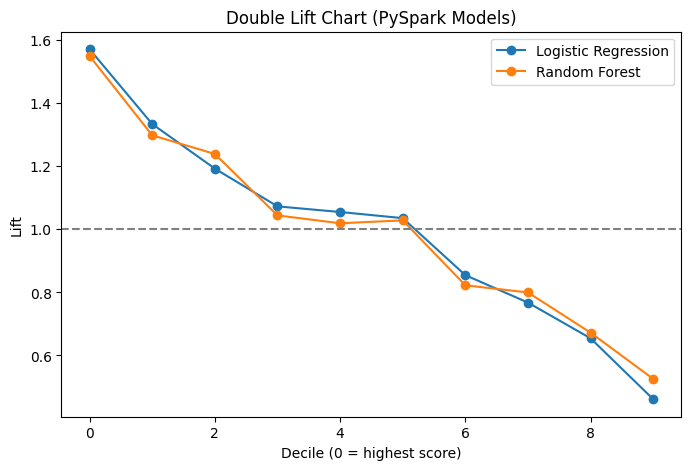

In [12]:
def lift_table(y_true, y_score, bins=10):
    df = pd.DataFrame({"y": y_true, "score": y_score})
    df = df.sort_values("score", ascending=False).reset_index(drop=True)

    #df["bin"] = pd.qcut(df["score"], bins, labels=False, duplicates="drop")
    df["bin"] = (df.index / len(df) * bins).astype(int)
    df["bin"] = df["bin"].clip(upper=bins - 1)

    grouped = df.groupby("bin")
    lift_df = pd.DataFrame({
        "events": grouped["y"].sum(),
        "total": grouped["y"].count()
    })
    lift_df = lift_df.dropna()
    lift_df["event_rate"] = lift_df["events"] / lift_df["total"]
    overall_rate = df["y"].mean()
    lift_df["lift"] = lift_df["event_rate"] / overall_rate

    return lift_df.reset_index()

plt.close('all') 

fig, ax = plt.subplots(figsize=(8,5))

ax.plot(lift_lr["bin"], lift_lr["lift"], marker="o", label="Logistic Regression")
ax.plot(lift_rf["bin"], lift_rf["lift"], marker="o", label="Random Forest")

ax.axhline(1, linestyle="--", color="gray")

ax.set_xlabel("Decile (0 = highest score)")
ax.set_ylabel("Lift")
ax.set_title("Double Lift Chart (PySpark Models)")
ax.legend()

plt.show()

In [13]:
print(lift_lr.head(20))
print(lift_rf.head(20))

   bin  events  total  event_rate      lift
0    0     440    659    0.667678  1.571120
1    1     373    658    0.566869  1.333905
2    2     334    659    0.506829  1.192623
3    3     300    658    0.455927  1.072846
4    4     295    658    0.448328  1.054965
5    5     290    659    0.440061  1.035511
6    6     239    658    0.363222  0.854701
7    7     215    659    0.326252  0.767706
8    8     183    658    0.278116  0.654436
9    9     129    658    0.196049  0.461324
   bin  events  total  event_rate      lift
0    0     434    659    0.658574  1.549696
1    1     363    658    0.551672  1.298144
2    2     347    659    0.526555  1.239042
3    3     292    658    0.443769  1.044237
4    4     285    658    0.433131  1.019204
5    5     288    659    0.437026  1.028369
6    6     230    658    0.349544  0.822515
7    7     224    659    0.339909  0.799843
8    8     188    658    0.285714  0.672317
9    9     147    658    0.223404  0.525695


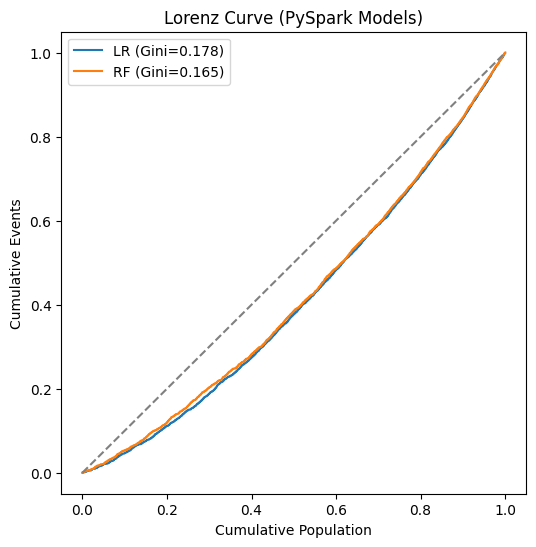

In [15]:
def lorenz_curve(y_true, y_score):
    df = pd.DataFrame({"y": y_true, "score": y_score})
    df = df.sort_values("score")

    df["cum_y"] = df["y"].cumsum()
    df["cum_pop"] = np.arange(1, len(df)+1)

    total_y = df["y"].sum()
    total_pop = len(df)

    lx = df["cum_pop"] / total_pop
    ly = df["cum_y"] / total_y

    return lx, ly

def gini_from_lorenz(lx, ly):
    area = np.trapz(ly, lx)
    return 1 - 2 * area

lx_lr, ly_lr = lorenz_curve(pdf["cancelled"], pdf["score_lr"])
lx_rf, ly_rf = lorenz_curve(pdf["cancelled"], pdf["score_rf"])

gini_lr = gini_from_lorenz(lx_lr, ly_lr)
gini_rf = gini_from_lorenz(lx_rf, ly_rf)

fig, ax = plt.subplots(figsize=(6,6))

ax.plot(lx_lr, ly_lr, label=f"LR (Gini={gini_lr:.3f})")
ax.plot(lx_rf, ly_rf, label=f"RF (Gini={gini_rf:.3f})")

ax.plot([0,1], [0,1], linestyle="--", color="gray")

ax.set_xlabel("Cumulative Population")
ax.set_ylabel("Cumulative Events")
ax.set_title("Lorenz Curve (PySpark Models)")
ax.legend()

plt.show()